# 01 - SPY Data Exploration

Download adjusted daily OHLCV data, inspect its quality, and save the raw dataset.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import download_data, save_raw_data

In [2]:
spy = download_data("SPY", "2010-01-01")
raw_path = save_raw_data(spy, "SPY", PROJECT_ROOT / "data" / "raw")
print(f"Saved {len(spy):,} rows to {raw_path}")
spy.head()

Saved 4,133 rows to /Users/satvikkadian/Documents/Financial ML Signal Lab/data/raw/SPY.csv


,date,open,high,low,close,volume
0,2010-01-04,84.078061,84.841248,83.434587,84.796356,118944600
1,2010-01-05,84.743958,85.058211,84.437183,85.020798,111579900
2,2010-01-06,84.938554,85.290221,84.871217,85.080719,116074400
3,2010-01-07,84.923565,85.544593,84.684133,85.439842,131091100
4,2010-01-08,85.215381,85.761588,85.043292,85.724174,126402800


In [3]:
spy.info()
spy.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4133 entries, 0 to 4132
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    4133 non-null   datetime64[ns]
 1   open    4133 non-null   float64       
 2   high    4133 non-null   float64       
 3   low     4133 non-null   float64       
 4   close   4133 non-null   float64       
 5   volume  4133 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 193.9 KB


,date,open,high,low,close,volume
count,4133,4133.000000,4133.000000,4133.000000,4133.000000,4.133000e+03
mean,2018-03-19 18:20:59.520929024,279.323280,280.817053,277.698569,279.378755,1.084021e+08
min,2010-01-04 00:00:00,77.835779,78.069790,76.341127,77.148834,2.027000e+07
25%,2014-02-11 00:00:00,149.514372,149.823067,148.685889,149.368164,6.488700e+07
50%,2018-03-20 00:00:00,234.671615,236.227684,233.055280,234.881073,8.889030e+07
75%,2022-04-26 00:00:00,394.352710,396.422478,391.600552,393.958466,1.312782e+08
max,2026-06-09 00:00:00,758.150024,760.400024,756.750000,759.570007,7.178287e+08
std,NaN,168.244972,169.091270,167.312198,168.281448,6.745125e+07


In [4]:
quality = {
    "start": spy["date"].min(),
    "end": spy["date"].max(),
    "duplicate_dates": int(spy["date"].duplicated().sum()),
    "missing_values": int(spy.isna().sum().sum()),
}
quality

{'start': Timestamp('2010-01-04 00:00:00'),
 'end': Timestamp('2026-06-09 00:00:00'),
 'duplicate_dates': 0,
 'missing_values': 0}

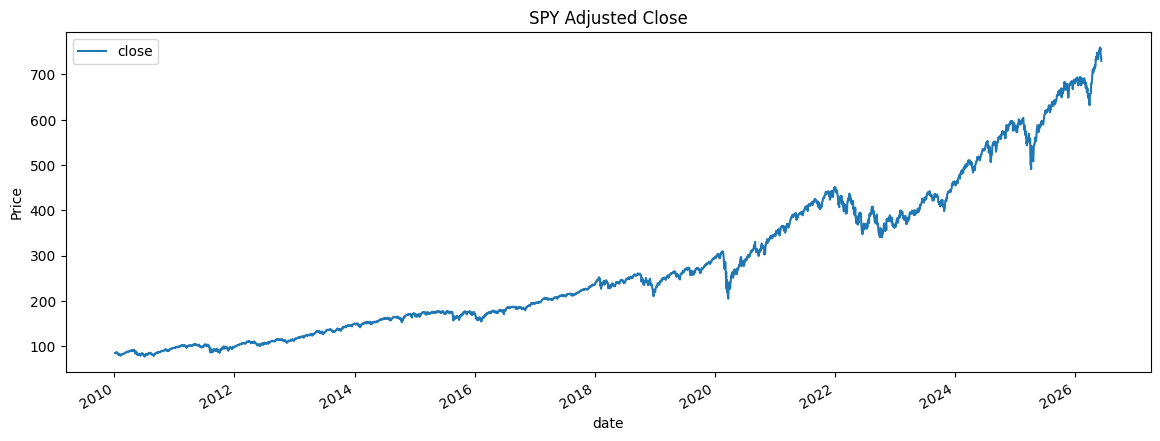

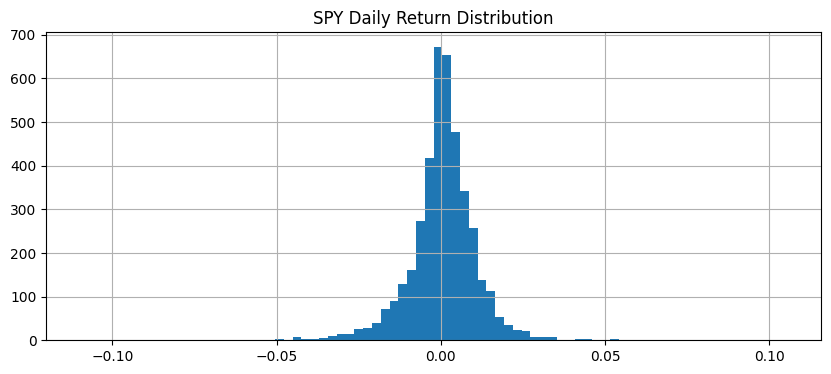

In [5]:
spy.plot(x="date", y="close", figsize=(14, 5), title="SPY Adjusted Close")
plt.ylabel("Price")
plt.show()

spy.assign(daily_return=spy["close"].pct_change())["daily_return"].hist(bins=80, figsize=(10, 4))
plt.title("SPY Daily Return Distribution")
plt.show()